# Predicting Best Picture: model and honest evaluation

**Question:** How well can the Oscar for *Best Picture* be predicted from precursor awards and Oscar nominations, and how reliable are hit rates like the ones reported in the literature?

**Data:** `data/processed/nominations.csv` from `run_pipeline.py`, one row per Best Picture nomination, target `won` (0/1). Only ceremonies from film year 1995 on are used, because all important guild awards exist from then on.

**Approach:**
1. How good are the precursor awards on their own, before and after 2010?
2. Model selection on the development years 2005–2014 only
3. Honest test on 2015–2026 (walk-forward: each year is predicted only from earlier years)
4. Comparison with the split protocol of the study by Butcher & Abbass (2026), which reports 85%
5. Which years were missed and what the model learned

The helper functions live in `src/oscar/model.py`. The most important rule everywhere: **splits keep whole ceremony years together**, and each year has exactly one film as the pick.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
try:
    import oscar  # installed via `uv sync`
except ImportError:
    sys.path.insert(0, str(ROOT / "src"))

from oscar.features import OUT_FILE
from oscar.model import (FEATURE_SETS, TARGET, YEAR, group_holdout, group_kfold, hits,
                         indicator_hit_rates, make_model, metrics, numeric_features,
                         plot_coefficients, plot_split_distribution, rule_baseline,
                         seed_stability, walk_forward, yearly_picks, years_with_winner)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data

One row per nomination. Each ceremony has exactly one winner and four to nine losers. That is why plain accuracy is misleading here: predicting "loses" for every film already scores almost 90%.

In [2]:
nominations = pd.read_csv(OUT_FILE)
data = nominations[nominations["year_film"] >= 1995].reset_index(drop=True)
FEATURE_SETS["All numeric features"] = numeric_features(data)

pd.Series({
    "Ceremonies": data[YEAR].nunique(),
    "Period": f"{data[YEAR].min()}–{data[YEAR].max()}",
    "Nominations": len(data),
    "Winners": int(data[TARGET].sum()),
    "Accuracy when always predicting 'loses'": f"{1 - data[TARGET].mean():.0%}",
}).to_frame("Value")

,Value
Ceremonies,31
Period,1996–2026
Nominations,226
Winners,31
Accuracy when always predicting 'loses',86%


## 2. How good are the precursor awards on their own?

How often did the winner of a precursor award also win Best Picture? Split into before and from 2010, because since the 2010 ceremony Best Picture has been decided by a **preferential ballot**, the system the PGA also uses, which presumably changed which precursor matters most. The Golden Globes are left out because they have two film categories and therefore two winners per year. BAFTA only counts from 2001, because before that its ceremony took place after the Oscars.

In [3]:
indicator_hit_rates(data, ["pga_win", "dga_win", "sag_win", "bafta_win", "cc_win"])

,until 2009,from 2010
PGA,8/14 (57%),14/17 (82%)
DGA,10/14 (71%),11/17 (65%)
SAG,7/14 (50%),8/17 (47%)
BAFTA,3/9 (33%),8/17 (47%)
CC,8/14 (57%),11/17 (65%)


## 3. Feature sets

Five sets are compared, from three guild awards up to all numeric columns. "Study" recreates the features of Butcher & Abbass (2026) with this project's columns.

In [4]:
pd.Series({name: f"{len(feats)}: " + ", ".join(feats) if len(feats) <= 8 else f"{len(feats)} columns"
           for name, feats in FEATURE_SETS.items()}, name="Features").to_frame()

,Features
Study (Butcher & Abbass),"7: dga_win, pga_win, oscar_total_noms, has_dir..."
PGA+DGA+SAG,"3: pga_win, dga_win, sag_win"
Guilds + BAFTA/CC,"5: pga_win, dga_win, sag_win, bafta_win, cc_win"
CORE,"8: pga_win, dga_win, sag_win, bafta_win, cc_wi..."
All numeric features,32 columns


## 4. Model selection on the development years 2005–2014

Each feature set is checked with walk-forward on 2005–2014, once without and once with extra weight on recent years (half-life of 10 or 5 years). The years from 2015 on stay untouched, so the later test number is not inflated by the selection: with so few years, some variant always gets lucky, and its hit rate would be too high. That is why we choose on different years than we test on.

Selection rule: most hits; on a tie, prefer no weighting and fewer features.

In [5]:
DEV_FIRST, DEV_LAST, TEST_FIRST = 2005, 2014, 2015
HALF_LIVES = {"none": None, "10 years": 10, "5 years": 5}

rows = []
for name, feats in FEATURE_SETS.items():
    for hl_label, hl in HALF_LIVES.items():
        pred = walk_forward(make_model(), data, feats, first=DEV_FIRST, last=DEV_LAST, half_life=hl)
        rows.append({"Feature set": name, "Weighting": hl_label, "Hits": hits(pred),
                     "Years": pred[YEAR].nunique(), "n_features": len(feats), "hl": hl})
dev = pd.DataFrame(rows)

pga_dev = rule_baseline(data, "pga_win", years_with_winner(data, DEV_FIRST, DEV_LAST))
print(f"For comparison, picking the PGA winner 2005–2014: {hits(pga_dev)}/{pga_dev[YEAR].nunique()}")

dev.pivot(index="Feature set", columns="Weighting", values="Hits")[list(HALF_LIVES)]

For comparison, picking the PGA winner 2005–2014: 7/10


Weighting,none,10 years,5 years
Feature set,,,
All numeric features,5,5,5
CORE,7,7,7
Guilds + BAFTA/CC,7,7,7
PGA+DGA+SAG,8,8,8
Study (Butcher & Abbass),7,7,7


In [6]:
best = (dev.assign(weighted=dev["hl"].notna())
           .sort_values(["Hits", "weighted", "n_features"], ascending=[False, True, True])
           .iloc[0])
CHOSEN_NAME = best["Feature set"]
CHOSEN_HL = None if pd.isna(best["hl"]) else float(best["hl"])
CHOSEN = FEATURE_SETS[CHOSEN_NAME]
print(f"Chosen: {CHOSEN_NAME}, weighting: {best['Weighting']} "
      f"({best['Hits']}/{best['Years']} on 2005–2014)")

Chosen: PGA+DGA+SAG, weighting: none (8/10 on 2005–2014)


## 5. Test: 2015–2026

The chosen model is tested once on the test years, with walk-forward: each year is predicted by a model trained only on the years before it, the way you would forecast before a real ceremony. For comparison: the study's features and two simple rules.

Because exactly one film is picked and exactly one film wins per year, **top-1, precision, recall and F1 are identical**. Accuracy over all rows only means something in comparison with "all lose".

In [7]:
test_years = years_with_winner(data, TEST_FIRST)
wf_chosen = walk_forward(make_model(), data, CHOSEN, first=TEST_FIRST, half_life=CHOSEN_HL)
wf_study = walk_forward(make_model(), data, FEATURE_SETS["Study (Butcher & Abbass)"], first=TEST_FIRST)
pga_test = rule_baseline(data, "pga_win", test_years)
noms_test = rule_baseline(data, "oscar_total_noms", test_years)

test_table = pd.DataFrame([
    metrics(f"Model: {CHOSEN_NAME}", wf_chosen),
    metrics("Model: study features", wf_study),
    metrics("Rule: PGA winner", pga_test),
    metrics("Rule: most nominations", noms_test),
]).set_index("Method")
test_table.round(2)

,Hits,Top-1,Precision,Recall,F1,ROC-AUC,Accuracy (rows),Accuracy 'all lose'
Method,,,,,,,,
Model: PGA+DGA+SAG,8/12,0.67,0.67,0.67,0.67,0.91,0.93,0.89
Model: study features,8/12,0.67,0.67,0.67,0.67,0.92,0.93,0.89
Rule: PGA winner,9/12,0.75,0.75,0.75,0.75,0.86,0.94,0.89
Rule: most nominations,4/12,0.33,0.33,0.33,0.33,0.64,0.85,0.89


## 6. The study's split protocol

Butcher & Abbass (2026) report a top-1 hit rate of 85% for Best Picture, measured with **one** random 80/20 split by ceremony year (`GroupShuffleSplit`). Here is the same protocol with the study's features, plus a 5-fold cross-validation by ceremony year in which every year is tested exactly once.

In [8]:
STUDY = FEATURE_SETS["Study (Butcher & Abbass)"]
study_table = pd.DataFrame([
    metrics("80/20 by ceremony year (seed 42)", group_holdout(make_model(), data, STUDY, seed=42)),
    metrics("5-fold by ceremony year", group_kfold(make_model(), data, STUDY)),
    metrics("Walk-forward from 2015", wf_study),
]).set_index("Method")
study_table.round(2)

,Hits,Top-1,Precision,Recall,F1,ROC-AUC,Accuracy (rows),Accuracy 'all lose'
Method,,,,,,,,
80/20 by ceremony year (seed 42),6/7,0.86,0.86,0.86,0.86,0.99,0.96,0.88
5-fold by ceremony year,20/31,0.65,0.65,0.65,0.65,0.89,0.90,0.86
Walk-forward from 2015,8/12,0.67,0.67,0.67,0.67,0.92,0.93,0.89


How random is a single 80/20 split? The same split with 50 different random seeds:

Mean 67% | range 29%–100% | share of splits with at least 85%: 20%


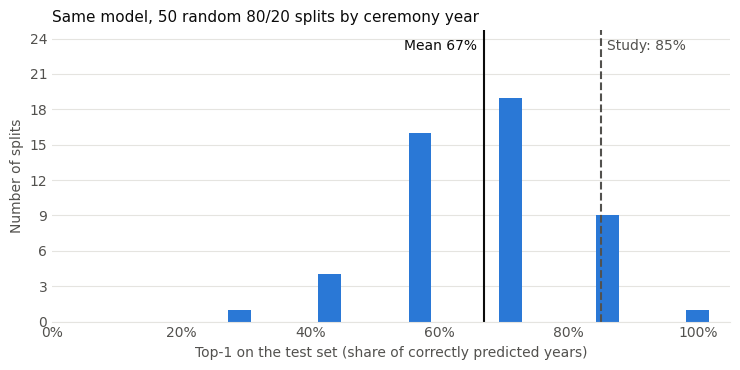

In [9]:
splits = seed_stability(make_model(), data, STUDY, n_seeds=50)
print(f"Mean {splits.mean():.0%} | range {splits.min():.0%}–{splits.max():.0%} | "
      f"share of splits with at least 85%: {(splits >= 0.85).mean():.0%}")

fig = plot_split_distribution(splits, reference=0.85, reference_label="Study")
fig.savefig(FIG_DIR / "split_stability.png", dpi=150, bbox_inches="tight")

## 7. Which years were missed?

For each test year: the chosen model's pick, the PGA rule's pick and the real winner. `p winner` is the probability the model gave the real winner.

In [10]:
yearly_picks(wf_chosen, baseline=pga_test)

,Winner,Model pick,p winner,Model correct,PGA pick,PGA correct
year_ceremony,,,,,,
2015,Birdman or (The Unexpected Virtue of Ignorance),Birdman or (The Unexpected Virtue of Ignorance),0.77,True,Birdman or (The Unexpected Virtue of Ignorance),True
2016,Spotlight,The Revenant,0.15,False,The Big Short,False
2017,Moonlight,La La Land,0.03,False,La La Land,False
2018,The Shape of Water,The Shape of Water,0.58,True,The Shape of Water,True
2019,Green Book,Roma,0.17,False,Green Book,True
2020,Parasite,1917,0.14,False,1917,False
2021,Nomadland,Nomadland,0.60,True,Nomadland,True
2022,CODA,CODA,0.53,True,CODA,True
2023,Everything Everywhere All at Once,Everything Everywhere All at Once,0.75,True,Everything Everywhere All at Once,True


## 8. What the model learned

Standardized coefficients of the logistic regression, trained on all years. Blue raises the chance of winning, red lowers it. The longer the bar, the more weight.

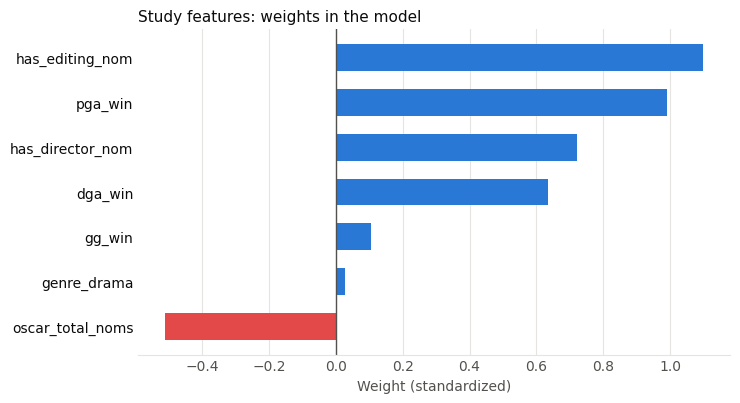

In [11]:
fig, coefs = plot_coefficients(make_model(), data, STUDY, "Study features: weights in the model")
fig.savefig(FIG_DIR / "coefficients_study.png", dpi=150, bbox_inches="tight")

`oscar_total_noms` gets a negative weight, even though more nominations should speak for a film. The reason: the number overlaps strongly with the Director and Film Editing nominations, and the model shifts weight between these columns. Coefficients therefore show how the model calculates, not what causes a win.

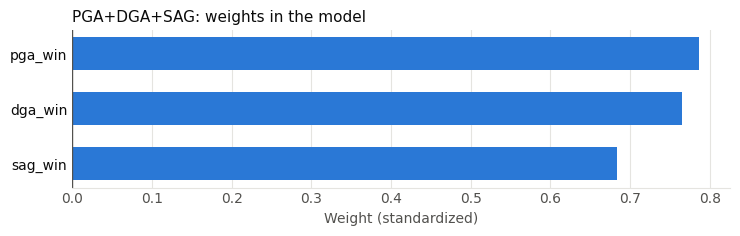

In [12]:
fig, coefs = plot_coefficients(make_model(), data, CHOSEN, f"{CHOSEN_NAME}: weights in the model")
fig.savefig(FIG_DIR / "coefficients_chosen.png", dpi=150, bbox_inches="tight")

## 9. Conclusion

*Numbers from the run on 7 October 2026. The 5-fold values can differ by one year between scikit-learn versions, because the assignment of ceremony years to folds can change.*

- **The precursor awards carry almost all the information.** Three guild awards (PGA, DGA, SAG) are enough. More features do not improve the forecast; all 32 numeric features even make it worse (5 instead of 8 of 10 hits on 2005–2014).
- **Things shifted around 2010.** Until 2009 the DGA was the best single indicator (10 of 14); since the preferential ballot it is the PGA (14 of 17). The model learns from all years and therefore gets 8 of 12 from 2015 on, behind the simple PGA rule with 9 of 12. The difference is exactly *Green Book* (2019): the model followed the DGA (*Roma*), the PGA was right.
- **The study's 85% is a lucky split.** With the same features and the same protocol, this project also gets 86% (6 of 7). Across 50 random splits, however, the mean is 67% (range 29–100%), and one split in five reaches 85% or more. 5-fold (65%) and walk-forward (67%) agree: about two thirds is realistic.
- **Real upsets stay unpredictable.** *Spotlight*, *Moonlight* and *Parasite* are missed by the model and the PGA rule alike.